<a href="https://colab.research.google.com/github/haridevsreebhavan/AI-Training-/blob/main/Assignments/Assignment_2/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [9]:
model = models.Sequential([

    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 57ms/step - accuracy: 0.9230 - loss: 0.2530 - val_accuracy: 0.9845 - val_loss: 0.0497
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 53ms/step - accuracy: 0.9786 - loss: 0.0728 - val_accuracy: 0.9870 - val_loss: 0.0408
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.9847 - loss: 0.0536 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9873 - loss: 0.0435 - val_accuracy: 0.9917 - val_loss: 0.0276
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9902 - loss: 0.0331 - val_accuracy: 0.9915 - val_loss: 0.0354
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9916 - loss: 0.0288 - val_accuracy: 0.9920 - val_loss: 0.0286
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9934 - loss: 0.0222 - val_accuracy: 0.9905 - val_loss: 0.0377
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9932 - loss: 0.0225 - 

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9931 - loss: 0.0305
Test Accuracy: 0.9930999875068665


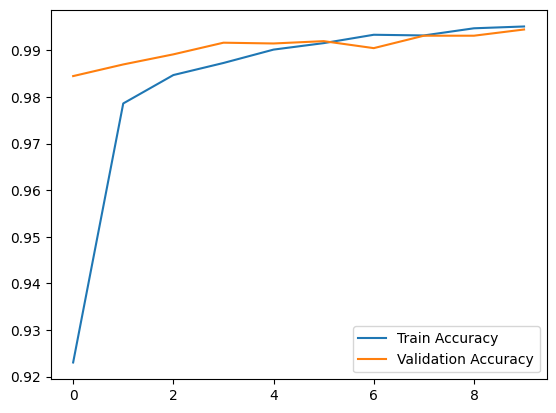

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [17]:
import cv2

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (28,28))
    img = img / 255.0

    img = 1 - img

    img = img.reshape(1,28,28,1)

    return img

In [18]:
img = preprocess_image("/content/test1.jpg")
pred = model.predict(img)

print("Predicted:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Predicted: 1


In [19]:
img = preprocess_image("/content/test2.jpg")
pred = model.predict(img)

print("Predicted:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: 6


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


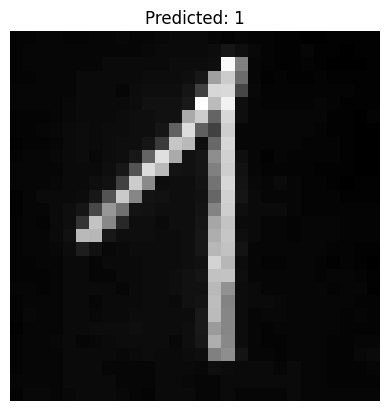

In [20]:
import matplotlib.pyplot as plt

img = preprocess_image("/content/test1.jpg")

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(model.predict(img))}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


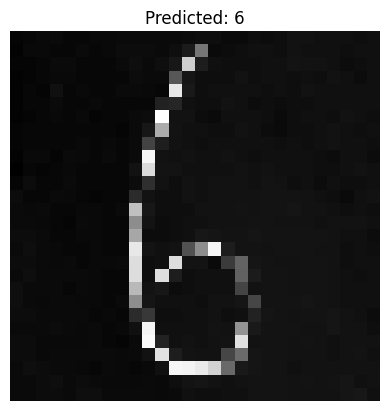

In [21]:
import matplotlib.pyplot as plt

img = preprocess_image("/content/test2.jpg")

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(model.predict(img))}")
plt.axis('off')
plt.show()

In [22]:
model.save("mnist_cnn_model.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


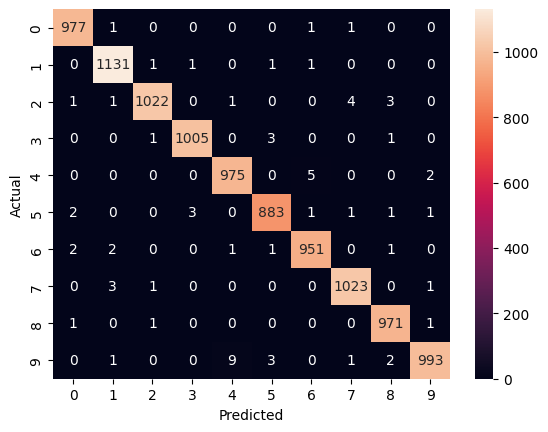

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()